An idea came to me:

At equilibrium the correlation function is given as 

$$\braket{ \sigma \sigma} = C(r)$$

and we know that away from equilibriu mthe function takes a scale invariant form:

$$\braket{ \sigma \sigma  }= C(r) f( r/\xi)$$

Now then, we also have an understanding that this form is still somewhat accurate with quenches, eg. 

$$\braket{\sigma \sigma }=  C(r) f(r/\sqrt{\tau}) $$

is it then true that 

$$\rho  \dot{=} \braket{\sigma\sigma} - \braket{\sigma\sigma(\tau)}= C(r) (1-f(r/\sqrt{\tau}))=  C(1) ( 1- f(1/\sqrt{\tau}))?$$

If this is true, then we have a direct (!) connection between the structure factor and the kibble zurek effect.

What is a good way to test this? Presumably with the $$\sigma^x, \sigma^z$$ ops. 

In [34]:
import sys

sys.path.append("../../src")

from equilibrium_critical_correlations import sigma_general as sigma_x

from equilibrium_z_projectors import sigma_general as sigma_z

import kibble_zurek as kz

from common_imports import *

from numpy.fft import fft, fftfreq, fftshift

foldername = "Figures/"




/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_48513/3373328149.py:14: RuntimeWarning: divide by zero encountered in power
  plot(r,r**(-2.)/6.28,"--k",label=r"$r^{-2}$")
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_48513/3373328149.py:15: RuntimeWarning: divide by zero encountered in power
  plot(r,r**(-1/4)/2,ls="-.", color="black", label=r"$r^{-1/4}$")
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_48513/3373328149.py:15: RuntimeWarning: invalid value encountered in power
  plot(r,r**(-1/4)/2,ls="-.", color="black", label=r"$r^{-1/4}$")


Text(0.5, 0, 'r')

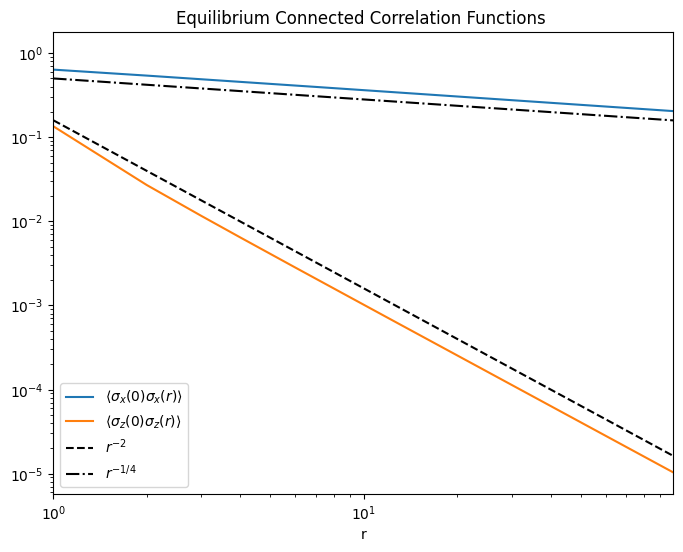

In [35]:
r = np.arange(-100,100)

xx_lab = r"$\langle \sigma_x (0) \sigma_x (r) \rangle $"
zz_lab = r"$\langle \sigma_z(0) \sigma_z (r) \rangle $"

C_xx = array([sigma_x([0,ri]) for ri in r])
C_zz = array([sigma_z([0,ri])- sigma_z([0])**2 for ri in r])


plt.figure(figsize=(8,6))

plot(r,C_xx,label= xx_lab)
plot(r,C_zz,label= zz_lab)
plot(r,r**(-2.)/6.28,"--k",label=r"$r^{-2}$")
plot(r,r**(-1/4)/2,ls="-.", color="black", label=r"$r^{-1/4}$")
legend()
xlim(1,max(r))
loglog()
title("Equilibrium Connected Correlation Functions ")
xlabel("r")

In [36]:
import kblock_ising_model as kb

L = 500
k = kb.k_vals(L)
delta_values = np.logspace(-3,-1,25)

states = [kb.U(k,1+d) for d in delta_values]


In [37]:
def xx(state,r):
    return array([kb.sigma_general([0,i],state,k ) for i in tqdm(r)])

In [38]:
X = [xx(state,r) for state in states]


  0%|          | 0/200 [00:00<?, ?it/s]/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/October /../../src/kblock_ising_model.py:146: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)
100%|██████████| 200/200 [00:35<00:00,  5.65it/s] 


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_48513/2408078838.py:4: RuntimeWarning: invalid value encountered in power
  scatter(r*d,((x)*r**(1/4)),label=str(d)[:6])


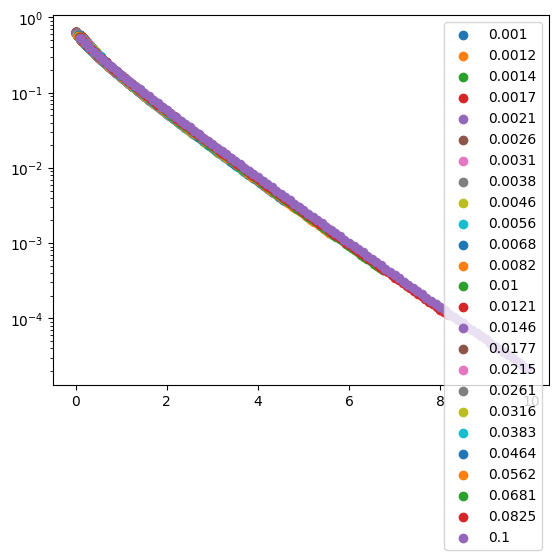

In [39]:
weird= []
for x,d in zip(X,delta_values):
    weird.append( (C_xx- x)[r==1])
    scatter(r*d,((x)*r**(1/4)),label=str(d)[:6])
legend()
yscale("log")

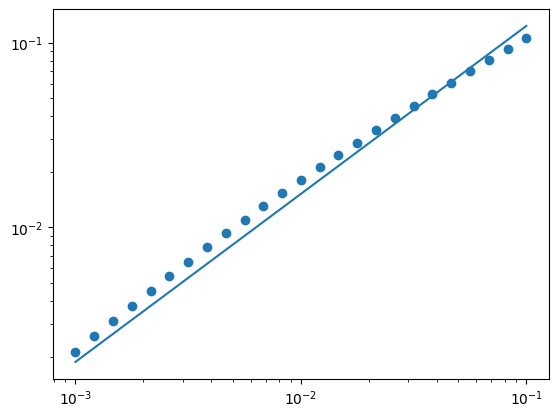

In [40]:
scatter(delta_values,weird)
plot(delta_values,delta_values**(3/3.3))
yscale('log')
xscale('log')

In [41]:

import kibble_zurek as kz
import time
L =500
taus = np.logspace(-2,3.5,20)
states = [kz.state(L,tau,0) for tau in taus]

In [42]:
import numpy as np

for i in range(len(states)):
    us, vs, k = states[i]
    us = np.array([complex(u) for u in us], dtype=np.complex128)
    vs = np.array([complex(v) for v in vs], dtype=np.complex128)
    k  = np.array(k, dtype=np.float64)
    states[i] = [us, vs, k]


In [43]:
kz.state(2,1,1)

[array([mpc(real='-0.4364593933239456214663392185301962531598663553266665190960580071008957132791998734538154514664862709128', imag='-0.5365596321448410767733188621036310546746153170367098047602397254733463939257375239398573846575647094195')],
       dtype=object),
 array([mpc(real='-0.6640375121844769626107244840107977361692942175226955387799213863622144419738714245383407013103181242492', imag='0.2840090518693669523461786167593121651928749535213376466489305758810655944592123420060995731495513608834')],
       dtype=object),
 array([1.57079633])]

In [44]:
def kxx(state,r):
    return array([kz.sigma_general([0,i],state) for i in r])

r = np.arange(-100,100)
Y = [kxx(state,r) for state in tqdm(states)]


100%|██████████| 20/20 [03:24<00:00, 10.21s/it]


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_48513/962216992.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  legend()


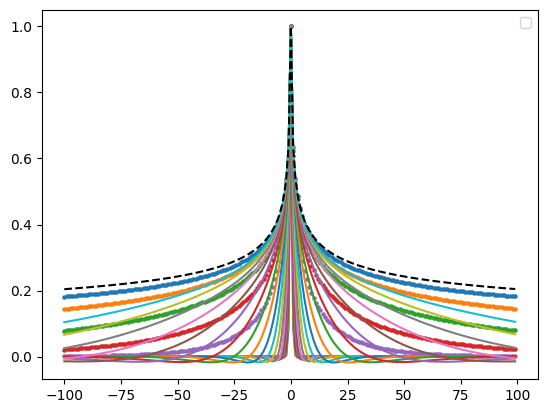

In [48]:
for y in Y:
    plot(r,y)
plot(r,C_xx,"--k")

for x in X[::5]:
     scatter(r,x,s=5)

legend()

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_48513/428322771.py:2: RuntimeWarning: invalid value encountered in power
  scatter(r*d,x*r**(1/4),s=1)


(1.0, 10.0)

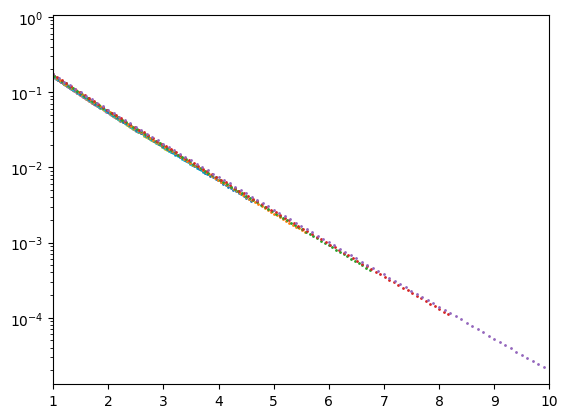

In [59]:
for x,d in zip(X,delta_values):
    scatter(r*d,x*r**(1/4),s=1)
yscale('log')
xlim(1,10)

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_48513/2968949489.py:3: RuntimeWarning: invalid value encountered in power
  plot(r/xi,abs(y*r**(1/4)),label=tau)


(1.0, 50.0)

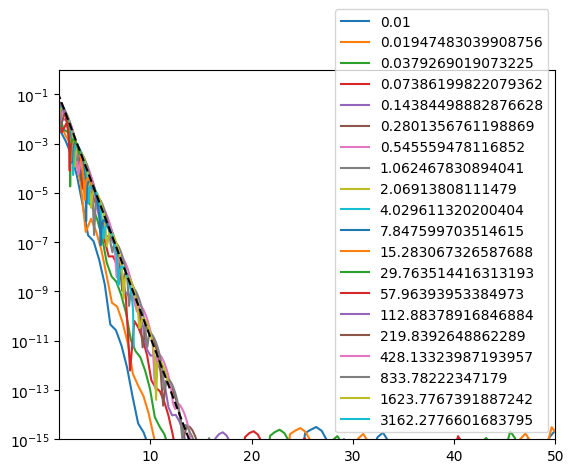

In [99]:
for y,tau,rho in zip(Y,taus,rhos):
    xi = 1/rho
    plot(r/xi,abs(y*r**(1/4)),label=tau)
legend()
plot(r,exp(-r*2.5),"--k")
#xscale('log')
ylim(0.000000000000001,1)
yscale('log')
xlim(1,50)

In [74]:
rhos = array([sigma_x([0,1])-kz.sigma_general([0,1],s) for s in states])

/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/October /../../src/kibble_zurek.py:211: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
